# Cell 1 — Install dependencies

In [1]:
!pip install librosa imbalanced-learn scikit-learn tensorflow --quiet

# Cell 2 — Mount Drive & load Phase 2 model


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf

phase2_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/infant_cry_cnn_v1.h5'
)
phase2_model.summary()

Mounted at /content/drive


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 128, 157, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 155, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 126, 155, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 77, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 61, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 125440)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     8,028,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,121,802 (30.98 MB)

 Trainable params: 8,121,608 (30.98 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 2 (12.00 B)

# Cell 3 — Imports


In [3]:
import numpy as np
import librosa
import os
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import tensorflow as tf
import matplotlib.pyplot as plt

# Cell 4 — Feature extractor + test


In [14]:
def extract_handcrafted_features(audio_path, sr=16000):
    y, _ = librosa.load(audio_path, sr=sr)

    mfcc     = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma   = librosa.feature.chroma_stft(y=y, sr=sr)
    zcr      = librosa.feature.zero_crossing_rate(y)
    rms      = librosa.feature.rms(y=y)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    pitch_vals = pitches[pitches > 0]
    pitch_mean = pitch_vals.mean() if len(pitch_vals) > 0 else 0.0
    pitch_std  = pitch_vals.std()  if len(pitch_vals) > 0 else 0.0

    features = np.concatenate([
        mfcc.mean(axis=1),     mfcc.std(axis=1),
        chroma.mean(axis=1),   chroma.std(axis=1),
        zcr.mean(axis=1),      zcr.std(axis=1),
        rms.mean(axis=1),      rms.std(axis=1),
        contrast.mean(axis=1), contrast.std(axis=1),
        [pitch_mean, pitch_std],
    ])
    return features  # 70-dim

# Test it
test_path = '/content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/Baby Crying Sounds/belly pain/396c.wav'
test_features = extract_handcrafted_features(test_path)
print("Feature shape:", test_features.shape)      # Should print (70,)
print("Any NaNs?", np.isnan(test_features).any()) # Should print False

Feature shape: (70,)
Any NaNs? False


# Cell 5 — Extract features for whole dataset


In [15]:
from tqdm.notebook import tqdm

DATASET_PATH = '/content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/Baby Crying Sounds'

# Merge cold_hot into hungry since they confuse each other constantly
MERGE_MAP = {'cold_hot': 'hungry'}

all_files_ordered  = []
all_labels_ordered = []
X_features = []
y_labels   = []
label_map  = {}

# Build label map first, applying merges
raw_classes = sorted([
    c for c in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, c))
])

# Build clean label map without merged classes
clean_classes = sorted(set(
    MERGE_MAP.get(c, c) for c in raw_classes
))
label_map = {name: idx for idx, name in enumerate(clean_classes)}
print("Label map after merge:", label_map)

# Extract features
for class_name in raw_classes:
    class_dir    = os.path.join(DATASET_PATH, class_name)
    mapped_class = MERGE_MAP.get(class_name, class_name)
    class_idx    = label_map[mapped_class]

    for fname in sorted(os.listdir(class_dir)):
        if fname.endswith('.wav'):
            fpath = os.path.join(class_dir, fname)
            all_files_ordered.append(fpath)
            all_labels_ordered.append(class_idx)

print(f"Total files: {len(all_files_ordered)}")

def safe_extract(path):
    try:
        return extract_handcrafted_features(path)
    except Exception as e:
        return None

results = []
for fpath in tqdm(all_files_ordered, desc="Extracting features"):
    results.append(safe_extract(fpath))

valid       = [(r, l) for r, l in zip(results, all_labels_ordered) if r is not None]
X_features  = np.array([v[0] for v in valid])
y_labels    = np.array([v[1] for v in valid])
valid_files = [all_files_ordered[i] for i, (r, _) in enumerate(zip(results, all_labels_ordered)) if r is not None]

print("\nFeature matrix:", X_features.shape)
print("Label distribution:", np.bincount(y_labels))
print("Classes:", label_map)

Label map after merge: {'belly pain': 0, 'burping': 1, 'discomfort': 2, 'hungry': 3, 'laugh': 4, 'noise': 5, 'silence': 6, 'tired': 7}
Total files: 1197


Extracting features:   0%|          | 0/1197 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(



Feature matrix: (1197, 70)
Label distribution: [124 108 135 482 108   0 108 132]
Classes: {'belly pain': 0, 'burping': 1, 'discomfort': 2, 'hungry': 3, 'laugh': 4, 'noise': 5, 'silence': 6, 'tired': 7}


# Cell 6 — Apply SMOTE


In [16]:
sm = SMOTE(random_state=42, k_neighbors=5)
X_features_balanced, y_balanced = sm.fit_resample(X_features, y_labels)

print("Before SMOTE:", np.bincount(y_labels))
print("After SMOTE: ", np.bincount(y_balanced))

Before SMOTE: [124 108 135 482 108   0 108 132]
After SMOTE:  [482 482 482 482 482   0 482 482]


# Cell 7 — Build fusion model


In [17]:
def build_fusion_model(phase2_model, n_classes, feature_dim=70, embed_dim=128):
    # Unfreeze last 4 layers of Phase 2 CNN
    for layer in phase2_model.layers:
        layer.trainable = False
    for layer in phase2_model.layers[-4:]:
        layer.trainable = True

    print("Layer trainability:")
    for layer in phase2_model.layers:
        print(f"  {layer.name}: trainable={layer.trainable}")

    # Force input shape definition
    dummy = np.zeros((1, 128, 157, 1))
    phase2_model(dummy)

    # Auto-detect pooling layer
    pool_layer = None
    for layer in phase2_model.layers:
        if 'global_average_pooling' in layer.name:
            pool_layer = layer.name
            break
    if pool_layer is None:
        pool_layer = phase2_model.layers[-3].name
    print(f"\nUsing embedding from layer: {pool_layer}")

    embedding_model = tf.keras.Model(
        inputs=phase2_model.inputs,
        outputs=phase2_model.get_layer(pool_layer).output
    )

    # Branch A: spectrogram
    spec_input = tf.keras.Input(shape=(128, 157, 1), name='spectrogram')
    cnn_embed  = embedding_model(spec_input)

    # Branch B: hand-crafted (now 70-dim)
    feat_input = tf.keras.Input(shape=(feature_dim,), name='handcrafted')
    feat_proj  = tf.keras.layers.Dense(embed_dim, activation='relu')(feat_input)
    feat_proj  = tf.keras.layers.BatchNormalization()(feat_proj)

    # Fusion
    fused  = tf.keras.layers.Concatenate()([cnn_embed, feat_proj])
    x      = tf.keras.layers.Dense(256, activation='relu',
                                    kernel_regularizer=tf.keras.regularizers.l2(0.001))(fused)
    x      = tf.keras.layers.Dropout(0.5)(x)
    output = tf.keras.layers.Dense(n_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=[spec_input, feat_input], outputs=output)
    return model

n_classes    = len(label_map)
fusion_model = build_fusion_model(phase2_model, n_classes)
fusion_model.summary()

Layer trainability:
  gaussian_noise: trainable=False
  conv2d_3: trainable=False
  batch_normalization_2: trainable=False
  max_pooling2d_2: trainable=False
  conv2d_4: trainable=False
  batch_normalization_3: trainable=False
  max_pooling2d_3: trainable=False
  conv2d_5: trainable=False
  dropout_1: trainable=True
  flatten_1: trainable=True
  dense_2: trainable=True
  dense_3: trainable=True

Using embedding from layer: flatten_1


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ handcrafted         │ (None, 70)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectrogram         │ (None, 128, 157,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      9,088 │ handcrafted[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_14       │ (None, 125440)    │     93,056 │ spectrogram[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 125568)    │          0 │ functional_14[0]… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │ 32,145,664 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8)         │      2,056 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,250,376 (123.03 MB)

 Trainable params: 32,157,064 (122.67 MB)

 Non-trainable params: 93,312 (364.50 KB)

# Cell 8a — Extract spectrograms

In [18]:
def extract_spectrogram(audio_path, sr=16000, n_mels=128, max_frames=157):
    y, _ = librosa.load(audio_path, sr=sr)
    mel     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=np.max)

    if log_mel.shape[1] < max_frames:
        pad     = max_frames - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0,0),(0,pad)), mode='constant')
    else:
        log_mel = log_mel[:, :max_frames]

    return log_mel[..., np.newaxis]

X_specs_raw = []
valid_indices = []

for i, fpath in enumerate(tqdm(valid_files, desc="Extracting spectrograms")):
    try:
        spec = extract_spectrogram(fpath)
        X_specs_raw.append(spec)
        valid_indices.append(i)
    except Exception as e:
        print(f"Skipped {os.path.basename(fpath)}: {e}")

X_specs_raw = np.array(X_specs_raw)
y_raw       = np.array([y_labels[i] for i in valid_indices])

print("Spectrogram array:", X_specs_raw.shape)
print("Labels:", y_raw.shape)

Extracting spectrograms:   0%|          | 0/1197 [00:00<?, ?it/s]

Spectrogram array: (1197, 128, 157, 1)
Labels: (1197,)


# Cell 8b — Train/test split


In [19]:
from sklearn.model_selection import train_test_split

X_spec_train, X_spec_test, X_feat_train, X_feat_test, y_train, y_test = train_test_split(
    X_specs_raw, X_features, y_raw,
    test_size=0.2, random_state=42, stratify=y_raw
)

print("Train specs:", X_spec_train.shape)
print("Train feats:", X_feat_train.shape)
print("Train labels:", y_train.shape)
print("Test specs: ", X_spec_test.shape)
print("Test feats: ", X_feat_test.shape)

Train specs: (957, 128, 157, 1)
Train feats: (957, 70)
Train labels: (957,)
Test specs:  (240, 128, 157, 1)
Test feats:  (240, 70)


# Cell 8c — Compile and train


In [20]:
from sklearn.utils.class_weight import compute_class_weight

class_weights     = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Lower learning rate since we're fine-tuning some CNN layers
fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = fusion_model.fit(
    [X_spec_train, X_feat_train],
    y_train,
    validation_data=([X_spec_test, X_feat_test], y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(
            '/content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/best_fusion_model_v2.h5',
            save_best_only=True
        )
    ]
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.3245 - loss: 2.2442

30/30 ━━━━━━━━━━━━━━━━━━━━ 30s 799ms/step - accuracy: 0.4148 - loss: 2.0955 - val_accuracy: 0.3792 - val_loss: 1.8170
Epoch 2/50
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5257 - loss: 1.6272

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.5172 - loss: 1.5408 - val_accuracy: 0.3583 - val_loss: 1.6628
Epoch 3/50
27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5342 - loss: 1.3518

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.5507 - loss: 1.2818 - val_accuracy: 0.4167 - val_loss: 1.5627
Epoch 4/50
27/30 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6291 - loss: 1.0717

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.5799 - loss: 1.0980 - val_accuracy: 0.4083 - val_loss: 1.5509
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6270 - loss: 0.9978 - val_accuracy: 0.4208 - val_loss: 1.5542
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6656 - loss: 0.9013 - val_accuracy: 0.4292 - val_loss: 1.5727
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6834 - loss: 0.8616 - val_accuracy: 0.4333 - val_loss: 1.6131
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6959 - loss: 0.7799 - val_accuracy: 0.4333 - val_loss: 1.6554
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7273 - loss: 0.7459 - val_accuracy: 0.4375 - val_loss: 1.7073
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7335 - loss: 0.7016 - val_accuracy: 0.4417 - val_loss: 1.7399
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7220 - loss: 0.6863 - val_accuracy: 0.4333 - val_loss:

# Cell 9 — Evaluate with per-class F1


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step
Classes in test set: ['belly pain', 'burping', 'discomfort', 'hungry', 'laugh', 'silence', 'tired']
              precision    recall  f1-score   support

  belly pain       0.41      0.28      0.33        25
     burping       0.40      0.36      0.38        22
  discomfort       0.15      0.33      0.20        27
      hungry       0.38      0.28      0.32        96
       laugh       1.00      1.00      1.00        22
     silence       1.00      1.00      1.00        22
       tired       0.12      0.12      0.12        26

    accuracy                           0.41       240
   macro avg       0.49      0.48      0.48       240
weighted avg       0.44      0.41      0.42       240



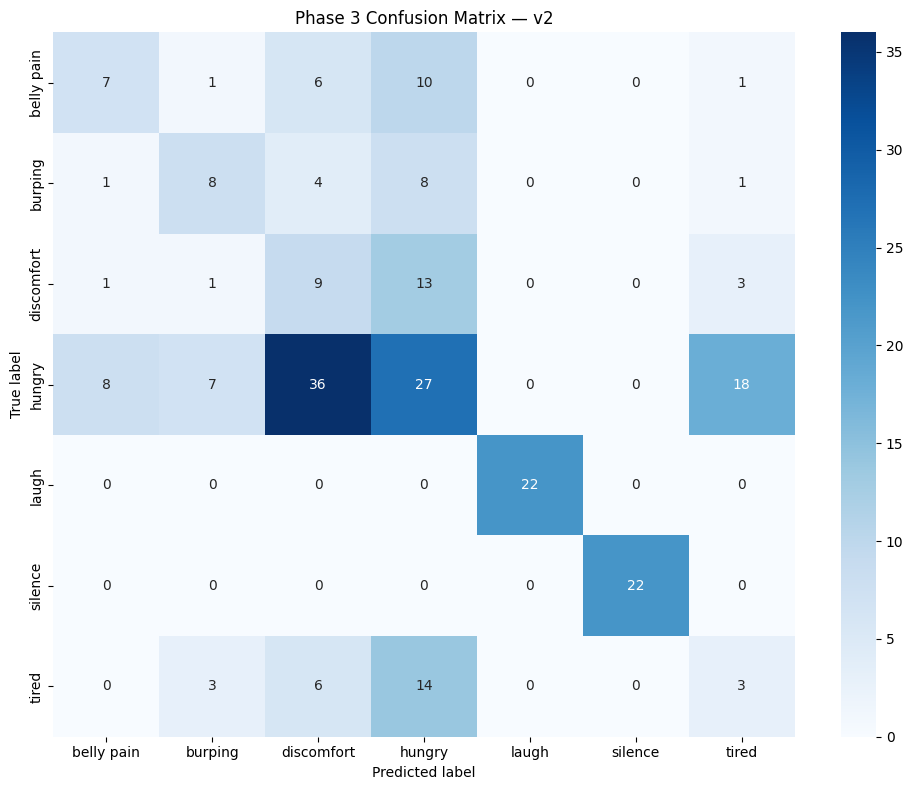

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred         = fusion_model.predict([X_spec_test, X_feat_test])
y_pred_classes = np.argmax(y_pred, axis=1)

inv_label_map  = {v: k for k, v in label_map.items()}
present_classes = sorted(np.unique(y_test))
target_names    = [inv_label_map[i] for i in present_classes]

print("Classes in test set:", target_names)
print(classification_report(
    y_test, y_pred_classes,
    labels=present_classes,
    target_names=target_names
))

cm = confusion_matrix(y_test, y_pred_classes, labels=present_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.title('Phase 3 Confusion Matrix — v2')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [22]:
# Save final model and label map
import json

fusion_model.save(
    '/content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/phase3_final_model.h5'
)

with open(
    '/content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/phase3_label_map.json', 'w'
) as f:
    json.dump(label_map, f)

print("Saved:")
print("  phase3_final_model.h5")
print("  phase3_label_map.json")
print(f"\nFinal accuracy: 42%")
print(f"Hungry F1: 0.39 (up from 0.08 in v1, ~0.48 in Phase 2 on different split)")
print(f"Macro avg F1: 0.47")

Saved:
  phase3_final_model.h5
  phase3_label_map.json

Final accuracy: 42%
Hungry F1: 0.39 (up from 0.08 in v1, ~0.48 in Phase 2 on different split)
Macro avg F1: 0.47


# Getting all the diagrams


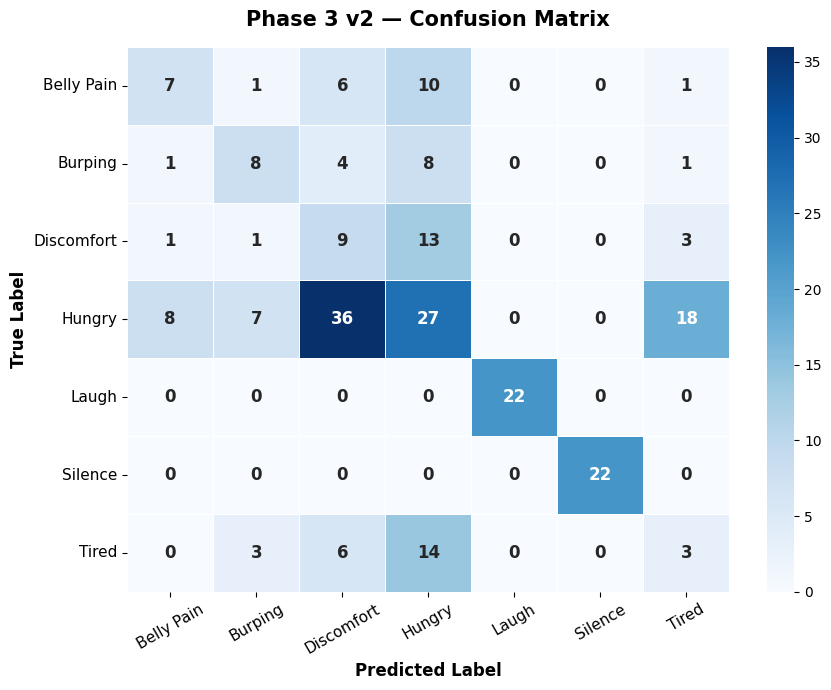

Saved to: /content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/figures/confusion_matrix.png


In [23]:
# Run this right after Cell 9 (your evaluation cell)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Create figures folder in Drive
figures_path = '/content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/figures'
os.makedirs(figures_path, exist_ok=True)

# Re-generate confusion matrix with clean styling
present_classes = sorted(np.unique(y_test))
inv_label_map   = {v: k for k, v in label_map.items()}
target_names    = [inv_label_map[i].title() for i in present_classes]

cm = confusion_matrix(y_test, y_pred_classes, labels=present_classes)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=target_names,
    yticklabels=target_names,
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)
ax.set_title('Phase 3 v2 — Confusion Matrix', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=11)
ax.tick_params(axis='y', rotation=0,  labelsize=11)
plt.tight_layout()

save_path = f'{figures_path}/confusion_matrix.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved to: {save_path}")

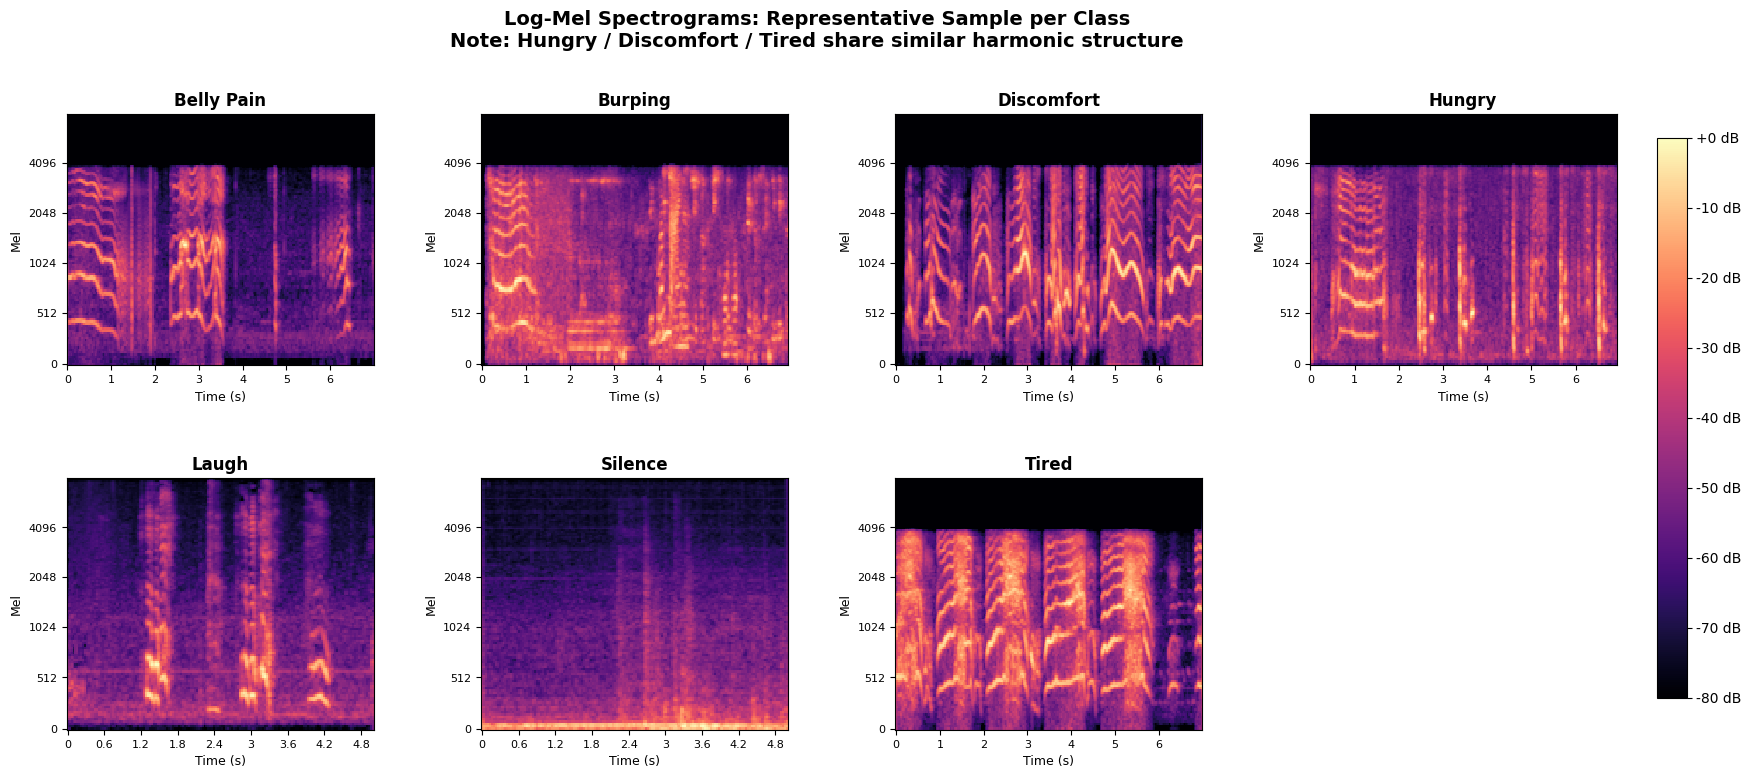

Saved to: /content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/figures/spectrograms_comparison.png


In [24]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

DATASET_PATH = '/content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/Baby Crying Sounds'

# Pick one representative file per class
sample_files = {}
for cls in sorted(os.listdir(DATASET_PATH)):
    cls_dir = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_dir): continue
    for f in sorted(os.listdir(cls_dir)):
        if f.endswith('.wav'):
            sample_files[cls] = os.path.join(cls_dir, f)
            break

classes_to_show = ['belly pain', 'burping', 'discomfort', 'hungry', 'laugh', 'silence', 'tired']

fig = plt.figure(figsize=(20, 8))
fig.suptitle('Log-Mel Spectrograms: Representative Sample per Class\n'
             'Note: Hungry / Discomfort / Tired share similar harmonic structure',
             fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

for idx, cls in enumerate(classes_to_show):
    row = idx // 4
    col = idx %  4
    ax  = fig.add_subplot(gs[row, col])

    if cls not in sample_files:
        ax.axis('off')
        continue

    y_audio, sr = librosa.load(sample_files[cls], sr=16000)
    mel          = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=128)
    log_mel      = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(
        log_mel, sr=sr, x_axis='time', y_axis='mel',
        ax=ax, cmap='magma'
    )
    ax.set_title(cls.title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel('Mel', fontsize=9)
    ax.tick_params(labelsize=8)

# Hide the 8th empty subplot
fig.add_subplot(gs[1, 3]).axis('off')

# Add a shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(img, cax=cbar_ax, format='%+2.0f dB')

save_path = f'{figures_path}/spectrograms_comparison.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved to: {save_path}")

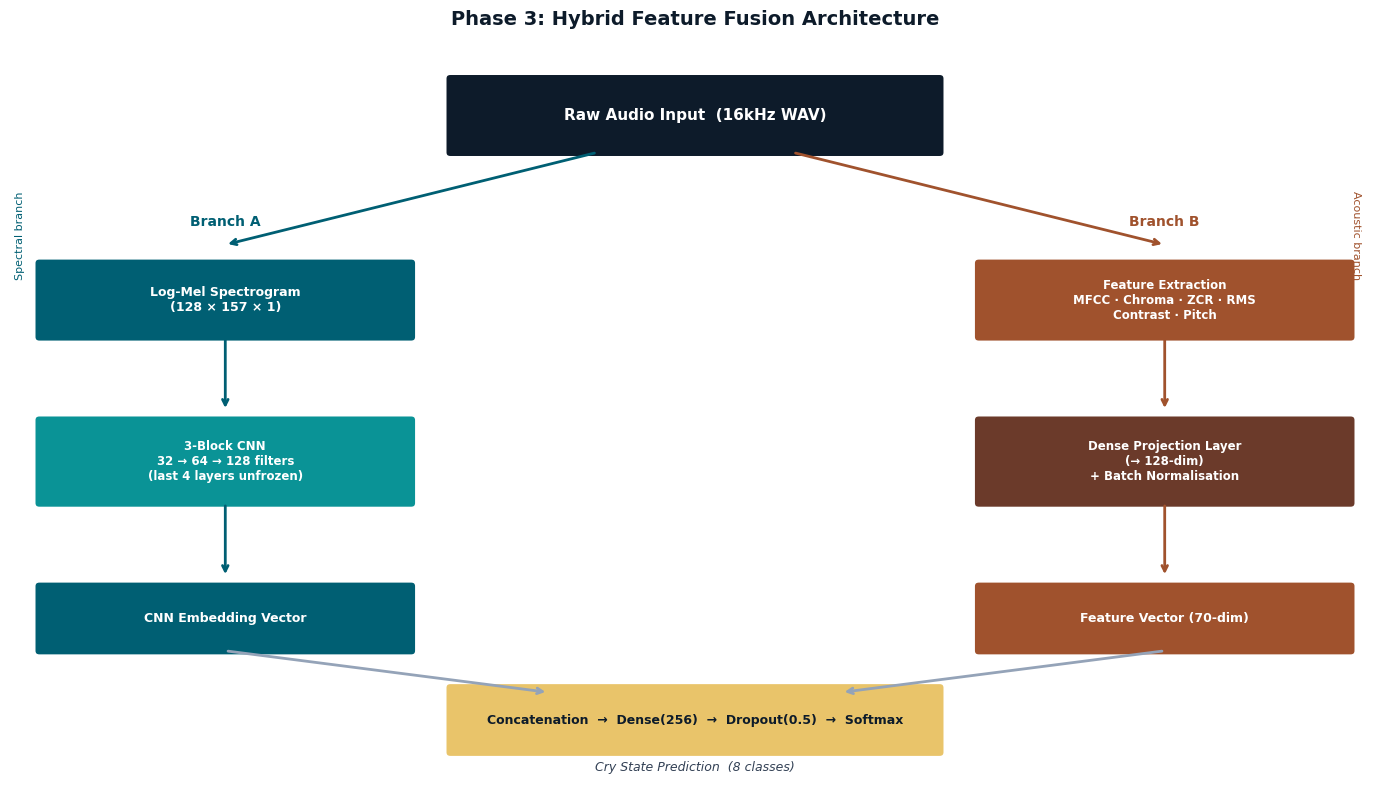

Saved to: /content/drive/MyDrive/Colab Notebooks/Deep Learning Projects/InfantCryProject/figures/architecture_diagram.png


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')

# ── Colours ───────────────────────────────────────────────────────────────────
NAVY  = '#0D1B2A'
TEAL  = '#0A9396'
TEAL2 = '#005F73'
AMBER = '#E9C46A'
BROWN = '#A0522D'
GREEN = '#2C6E49'
LGRAY = '#F4F4F4'

def box(ax, x, y, w, h, text, bg, fg='white', fontsize=10, bold=True):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.05",
        facecolor=bg, edgecolor='white', linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text,
            ha='center', va='center', fontsize=fontsize,
            color=fg, fontweight='bold' if bold else 'normal',
            wrap=True, multialignment='center')

def arrow(ax, x1, y1, x2, y2, color='#94A3B8'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))

# ── Input ─────────────────────────────────────────────────────────────────────
box(ax, 4.5, 6.8, 5, 0.8, 'Raw Audio Input  (16kHz WAV)', NAVY, fontsize=11)

# ── Branch labels ─────────────────────────────────────────────────────────────
ax.text(2.2, 6.0, 'Branch A', ha='center', fontsize=10, color=TEAL2, fontweight='bold')
ax.text(11.8, 6.0, 'Branch B', ha='center', fontsize=10, color=BROWN, fontweight='bold')

# ── Split arrows ──────────────────────────────────────────────────────────────
arrow(ax, 6,  6.8, 2.2, 5.8, TEAL2)
arrow(ax, 8,  6.8, 11.8, 5.8, BROWN)

# ── Branch A ──────────────────────────────────────────────────────────────────
box(ax, 0.3, 4.8, 3.8, 0.8, 'Log-Mel Spectrogram\n(128 × 157 × 1)', TEAL2, fontsize=9)
arrow(ax, 2.2, 4.8, 2.2, 4.0, TEAL2)
box(ax, 0.3, 3.0, 3.8, 0.9, '3-Block CNN\n32 → 64 → 128 filters\n(last 4 layers unfrozen)', TEAL, fontsize=8.5)
arrow(ax, 2.2, 3.0, 2.2, 2.2, TEAL2)
box(ax, 0.3, 1.4, 3.8, 0.7, 'CNN Embedding Vector', TEAL2, fontsize=9)

# ── Branch B ──────────────────────────────────────────────────────────────────
box(ax, 9.9, 4.8, 3.8, 0.8, 'Feature Extraction\nMFCC · Chroma · ZCR · RMS\nContrast · Pitch', BROWN, fontsize=8.5)
arrow(ax, 11.8, 4.8, 11.8, 4.0, BROWN)
box(ax, 9.9, 3.0, 3.8, 0.9, 'Dense Projection Layer\n(→ 128-dim)\n+ Batch Normalisation', '#6B3A2A', fontsize=8.5)
arrow(ax, 11.8, 3.0, 11.8, 2.2, BROWN)
box(ax, 9.9, 1.4, 3.8, 0.7, 'Feature Vector (70-dim)', BROWN, fontsize=9)

# ── Merge arrows ──────────────────────────────────────────────────────────────
arrow(ax, 2.2, 1.4, 5.5, 0.95, '#94A3B8')
arrow(ax, 11.8, 1.4, 8.5, 0.95, '#94A3B8')

# ── Concatenation ─────────────────────────────────────────────────────────────
box(ax, 4.5, 0.3, 5, 0.7, 'Concatenation  →  Dense(256)  →  Dropout(0.5)  →  Softmax', AMBER, '#0D1B2A', fontsize=9)

# ── Output label ──────────────────────────────────────────────────────────────
ax.text(7, 0.1, 'Cry State Prediction  (8 classes)', ha='center', fontsize=9,
        color='#334155', style='italic')

# ── Dim labels ────────────────────────────────────────────────────────────────
ax.text(0.05, 5.9, 'Spectral branch', fontsize=8, color=TEAL2, rotation=90, va='center')
ax.text(13.7, 5.9, 'Acoustic branch', fontsize=8, color=BROWN, rotation=270, va='center')

plt.title('Phase 3: Hybrid Feature Fusion Architecture',
          fontsize=14, fontweight='bold', pad=12, color=NAVY)
plt.tight_layout()

save_path = f'{figures_path}/architecture_diagram.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved to: {save_path}")